# 1 Setup & Loading the dataset

In [37]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


print("All libraries loaded successfully.")

All libraries loaded successfully.


In [38]:
df = pd.read_csv("dataset/diabetes_012_health_indicators_BRFSS2015.csv")
# renaming for clarity
df.rename(columns={'Diabetes_012': 'Target'}, inplace=True)
print(f"Dataset loaded successfully. Total {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded successfully. Total 253680 rows and 22 columns.


,Target,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# 2. Exploratory Data Analysis (EDA)
## 2.1 General information about dataset
Looking for variable types and any missing values

In [39]:
print("\nColumn types:")
print(df.dtypes.value_counts())

print("\nMissing values:", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())



Column types:
float64    22
Name: count, dtype: int64

Missing values: 0

Duplicate rows: 23899


In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Target,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


# 2.2 Disbalance of classes
Dataset contains 3 classes, with significant disbalance
 - 0 - No diabetes
 - 1 - Prediabetes
 - 2 - Diabetes

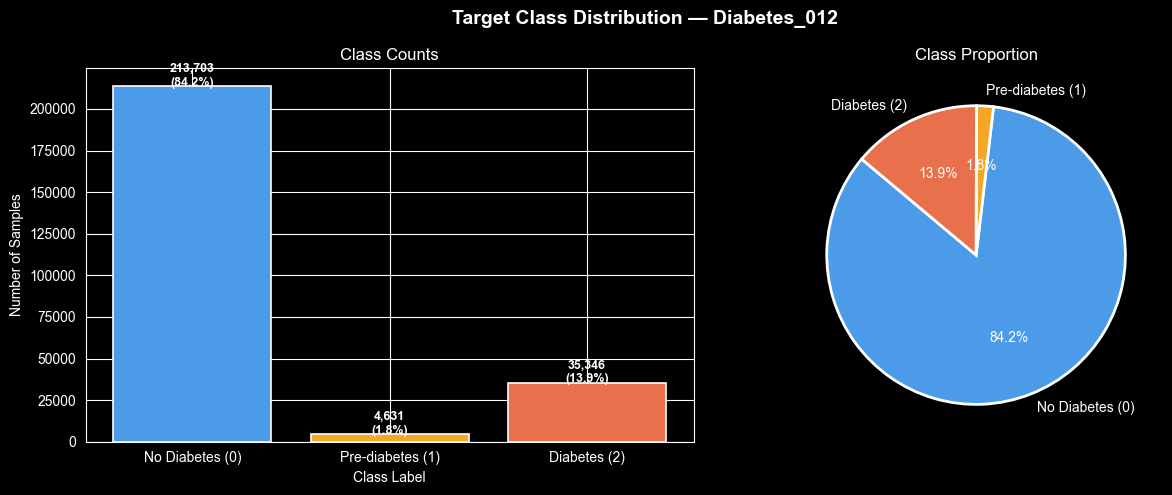

Class breakdown:
  Class 0 (No Diabetes (0)): 213,703  (84.24%)
  Class 1 (Pre-diabetes (1)): 4,631  (1.83%)
  Class 2 (Diabetes (2)): 35,346  (13.93%)

Imbalance ratio (max/min): 46.1:1


In [41]:
counts = df['Target'].value_counts().sort_index()
labels = ['No Diabetes (0)', 'Pre-diabetes (1)', 'Diabetes (2)']
colors = ['#4C9BE8', '#F5A623', '#E8704C']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Target Class Distribution — Diabetes_012', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Counts')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xlabel('Class Label')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 300,
                 f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

print("Class breakdown:")
for i, (cls, cnt) in enumerate(counts.items()):
    print(f"  Class {int(cls)} ({labels[i]}): {cnt:,}  ({cnt/len(df)*100:.2f}%)")

print(f"\nImbalance ratio (max/min): {counts.max()/counts.min():.1f}:1")

**Conclusion:** number of class 1 is very low

Accuracy will make mistakes

Will compensate with class_weight="balanced" in all models


# 2.3 Distribution of numeric and ordinal features

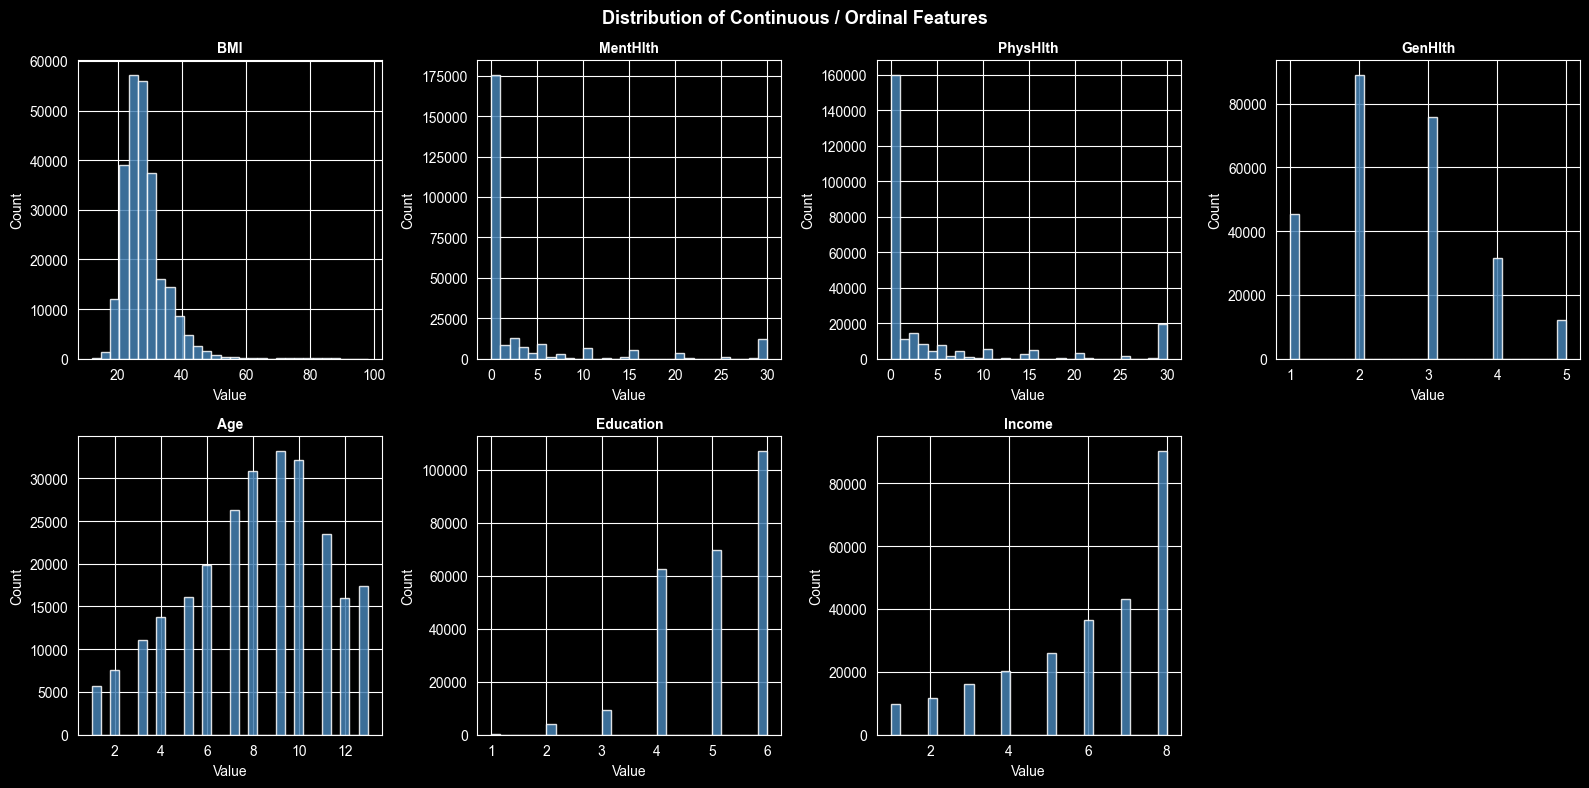

In [42]:
continuous_cols = ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age', 'Education', 'Income']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution of Continuous / Ordinal Features', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

## 2.4 Binary Features vs. Target Variable
Diabetes class rate, listed by each binary feature group

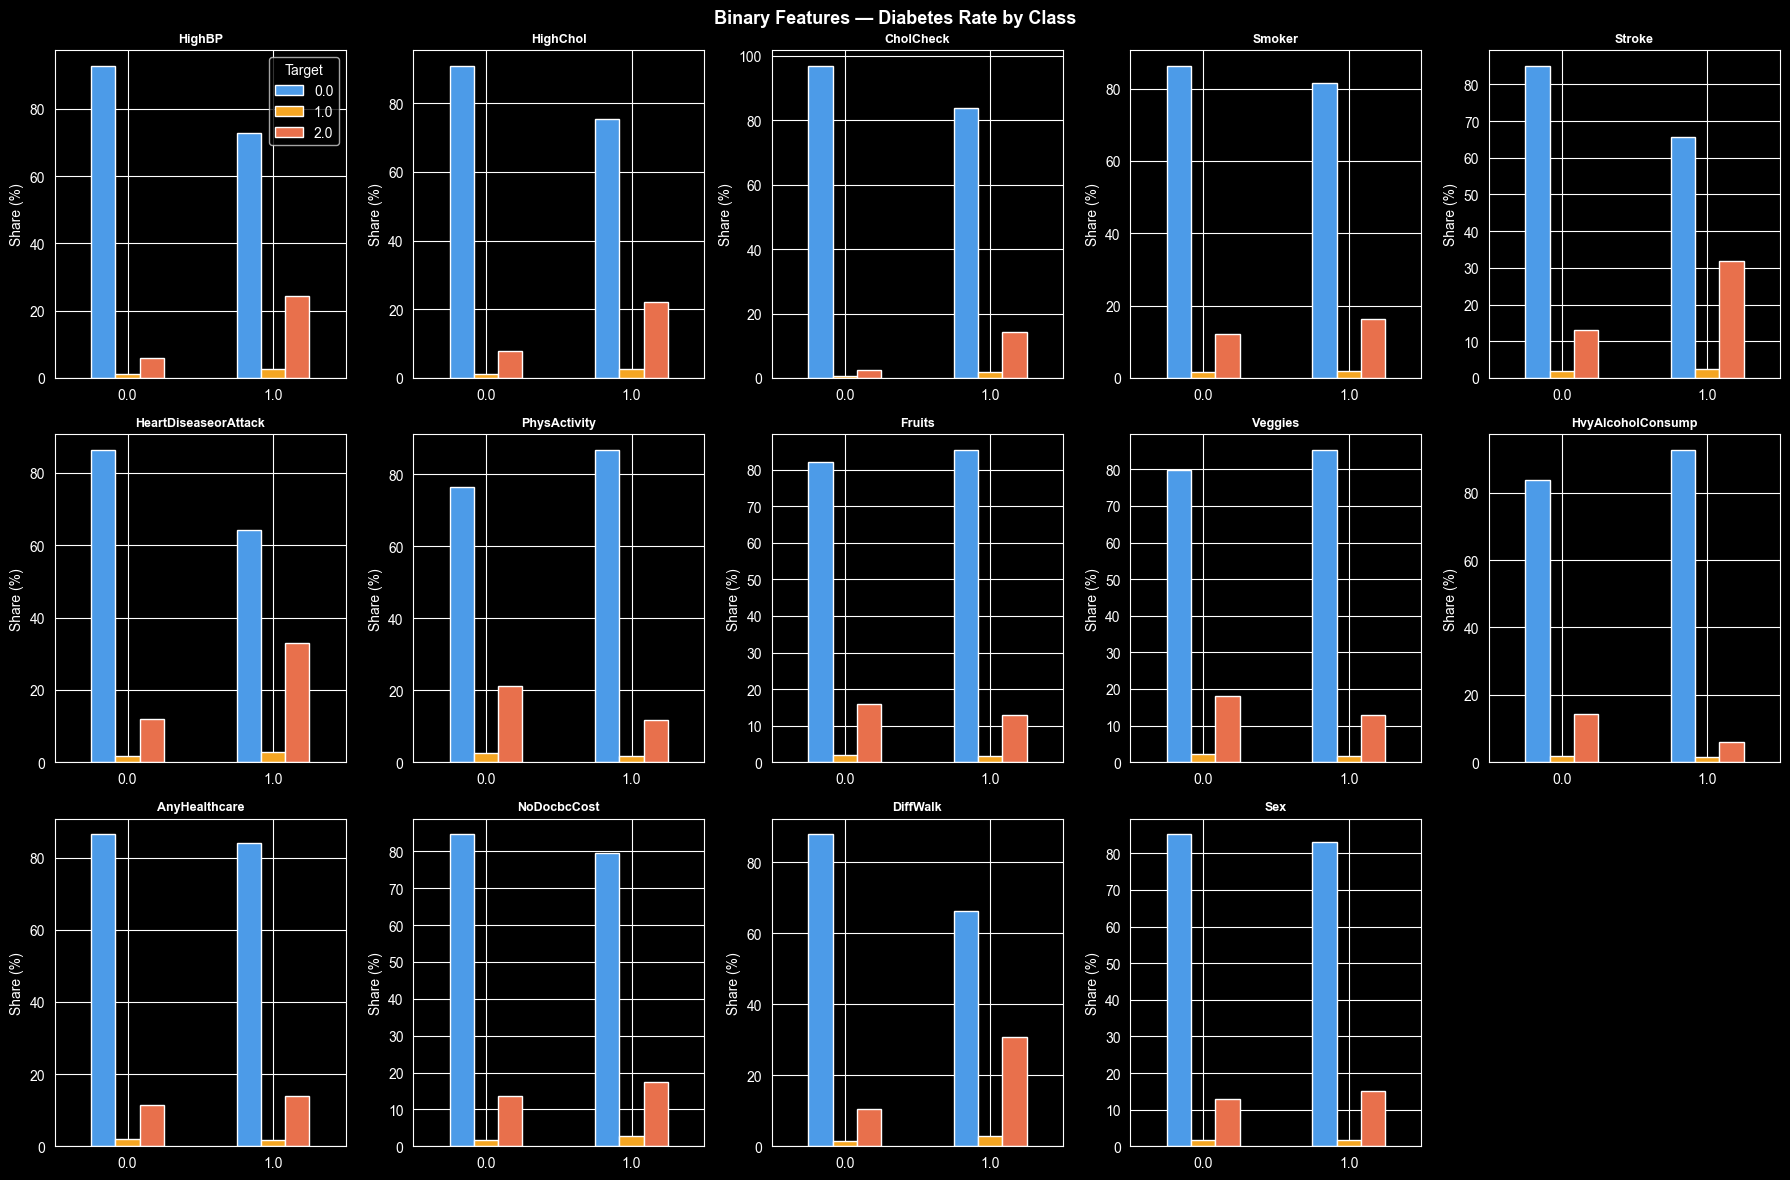

In [43]:
binary_cols = [c for c in df.columns if c not in continuous_cols + ['Target']]

fig, axes = plt.subplots(3, 5, figsize=(18, 12))
fig.suptitle('Binary Features — Diabetes Rate by Class', fontsize=13, fontweight='bold')
axes = axes.flatten()

colors_cls = ['#4C9BE8', '#F5A623', '#E8704C']

for i, col in enumerate(binary_cols[:15]):
    rate = df.groupby(col)['Target'].value_counts(normalize=True).unstack(fill_value=0) * 100
    rate.plot(kind='bar', ax=axes[i], color=colors_cls[:rate.shape[1]],
              edgecolor='white', legend=(i == 0))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Share (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('binary_features_vs_target.png', bbox_inches='tight')
plt.show()


# 2.5 Numerical features vs Target Variable

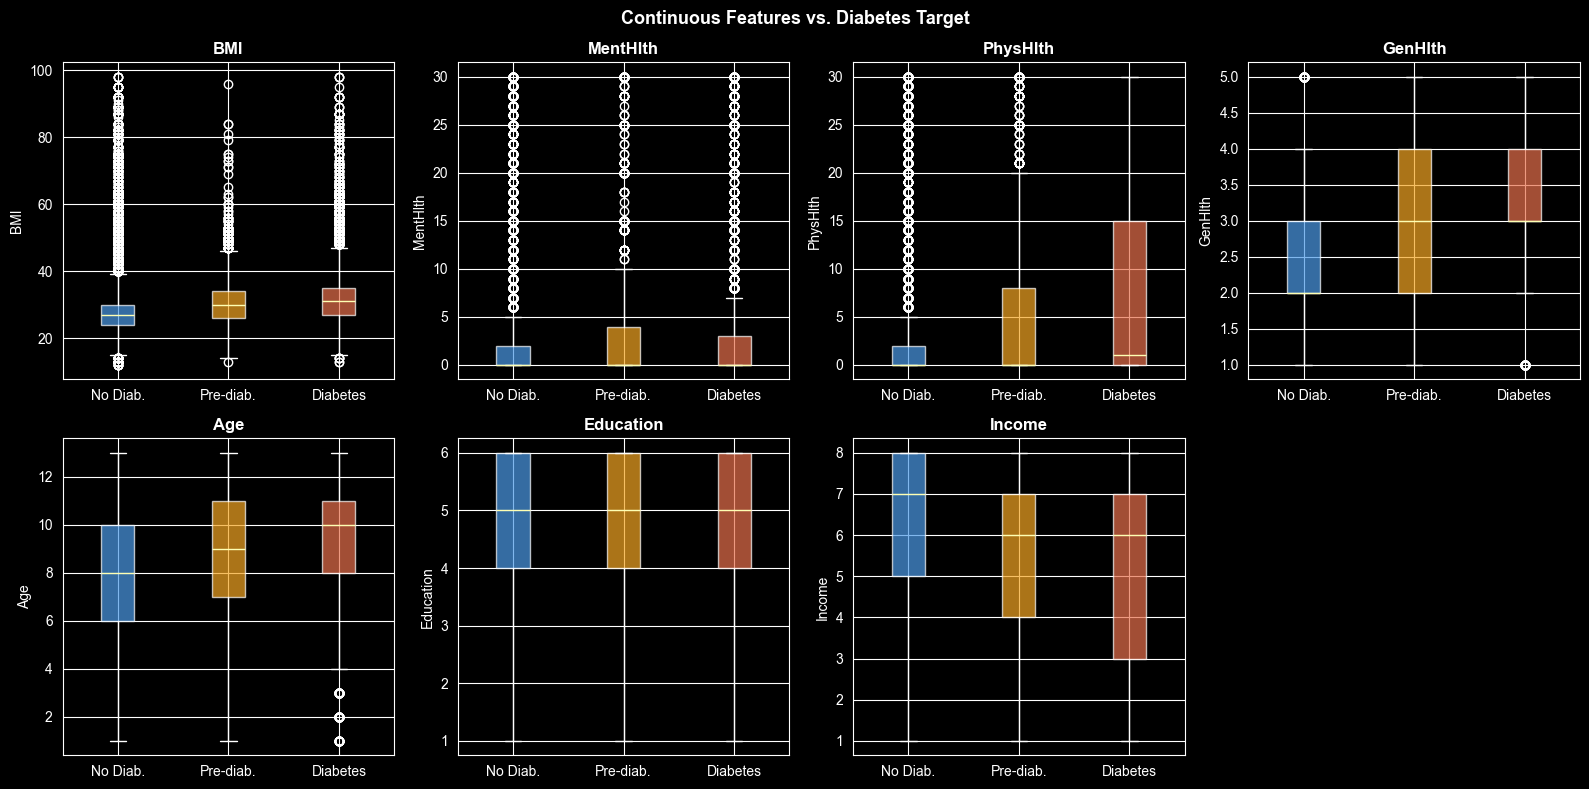

In [44]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Continuous Features vs. Diabetes Target', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    data_by_class = [df[df['Target'] == cls][col].values for cls in [0, 1, 2]]
    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                         tick_labels=['No Diab.', 'Pre-diab.', 'Diabetes'])
    for patch, color in zip(bp['boxes'], colors_cls):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('boxplots_vs_target.png', bbox_inches='tight')
plt.show()

## 2.6 Correlation Heatmap

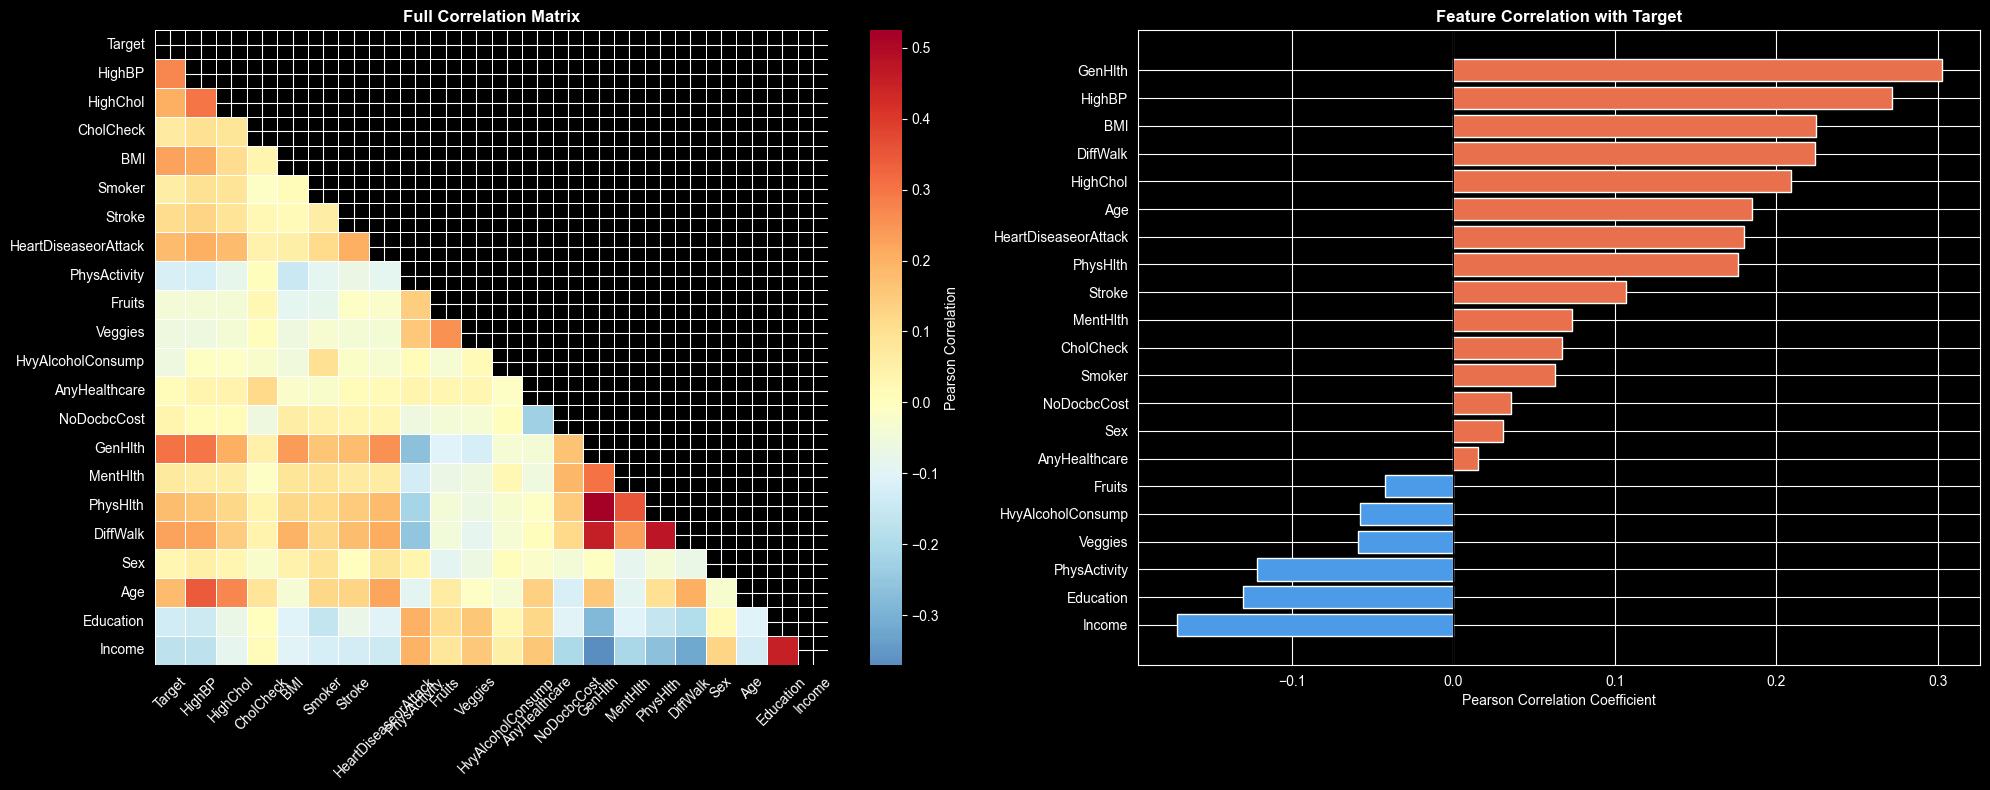

Top-10 features by |correlation| with Target:
GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Income                  0.171483
Education               0.130517


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, ax=axes[0],
            cmap='RdYlBu_r', center=0, annot=False,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Pearson Correlation'})
axes[0].set_title('Full Correlation Matrix', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Correlation with target — bar chart
target_corr = corr['Target'].drop('Target').sort_values()
colors_bar = ['#E8704C' if v > 0 else '#4C9BE8' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Target', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("Top-10 features by |correlation| with Target:")
print(corr['Target'].drop('Target').abs().sort_values(ascending=False).head(10).to_string())


**Takeaway:** `GenHlth`, `BMI`, `Age`, `HighBP`, `HighChol`, `DiffWalk` are the most strongly correlated with diabetes.

`PhysActivity`, `Fruits`, `Veggies` show negative correlation (protective factors).

## 2.7 Analysis of Outliers

In [46]:
print("Outlier Analysis (IQR method):")
print("-" * 42)
for col in continuous_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:<15}: {n_out:>6,} outliers ({n_out/len(df)*100:.2f}%)")


Outlier Analysis (IQR method):
------------------------------------------
  BMI            :  9,847 outliers (3.88%)
  MentHlth       : 36,208 outliers (14.27%)
  PhysHlth       : 40,949 outliers (16.14%)
  GenHlth        : 12,081 outliers (4.76%)
  Age            :      0 outliers (0.00%)
  Education      :      0 outliers (0.00%)
  Income         :      0 outliers (0.00%)


# 3. Data Preprocessing

What is going to be used:
 - Stratified **Train/Test/Val** (60/20/20)
 - **StandartScaler**
 - **class_weight='balanced'** in all models against disbalance or imbalance
 - PCA for visualization

In [47]:
feature_cols = [c for c in df.columns if c != 'Target']
X = df[feature_cols].copy()
y = df['Target'].copy().astype(int)

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]:,}")
print(f"Classes: {sorted(y.unique())}  |  Distribution: {y.value_counts().to_dict()}")

Features: 21  |  Samples: 253,680
Classes: [np.int64(0), np.int64(1), np.int64(2)]  |  Distribution: {0: 213703, 2: 35346, 1: 4631}


In [48]:
# Stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Split summary (stratified):")
for name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = ys.value_counts(normalize=True).sort_index().round(3).to_dict()
    print(f"  {name:<6}: {len(ys):>6,} samples | class ratios: {dist}")

Split summary (stratified):
  Train : 152,208 samples | class ratios: {0: 0.842, 1: 0.018, 2: 0.139}
  Val   : 50,736 samples | class ratios: {0: 0.842, 1: 0.018, 2: 0.139}
  Test  : 50,736 samples | class ratios: {0: 0.842, 1: 0.018, 2: 0.139}


In [49]:
# StandardScaler — fit on train only (prevent data leakage)
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),       columns=feature_cols)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print("StandardScaler applied.")
print(f"  Train mean (should be ≈ 0): {X_train_sc.mean().mean():.6f}")
print(f"  Train std  (should be ≈ 1): {X_train_sc.std().mean():.6f}")

StandardScaler applied.
  Train mean (should be ≈ 0): 0.000000
  Train std  (should be ≈ 1): 1.000003


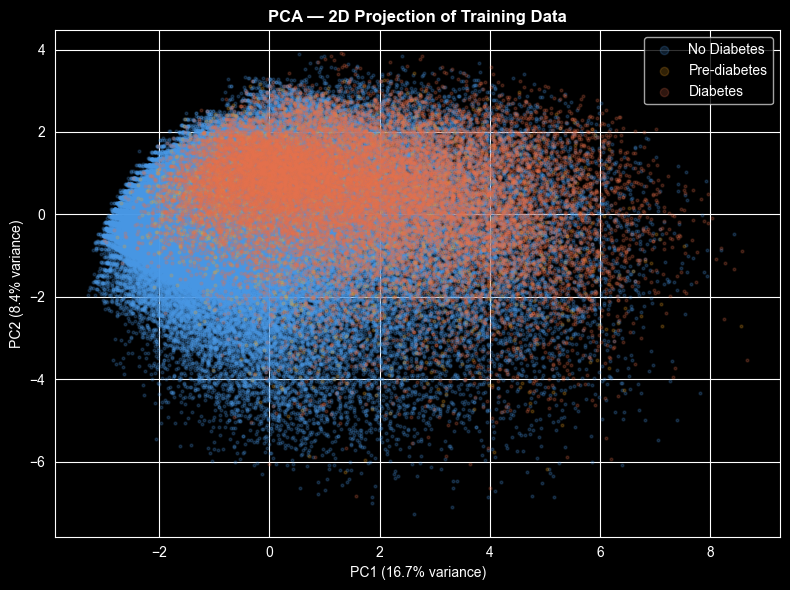

2 PCs explain 25.1% of total variance


In [50]:
# PCA — 2D visualization
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_train_sc)

fig, ax = plt.subplots(figsize=(8, 6))
cls_labels = {0: 'No Diabetes', 1: 'Pre-diabetes', 2: 'Diabetes'}
for cls, color in zip([0, 1, 2], colors_cls):
    mask = y_train.values == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.2, s=4, label=cls_labels[cls])

ax.set_title('PCA — 2D Projection of Training Data', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('pca_projection.png', bbox_inches='tight')
plt.show()

print(f"2 PCs explain {sum(pca2.explained_variance_ratio_)*100:.1f}% of total variance")

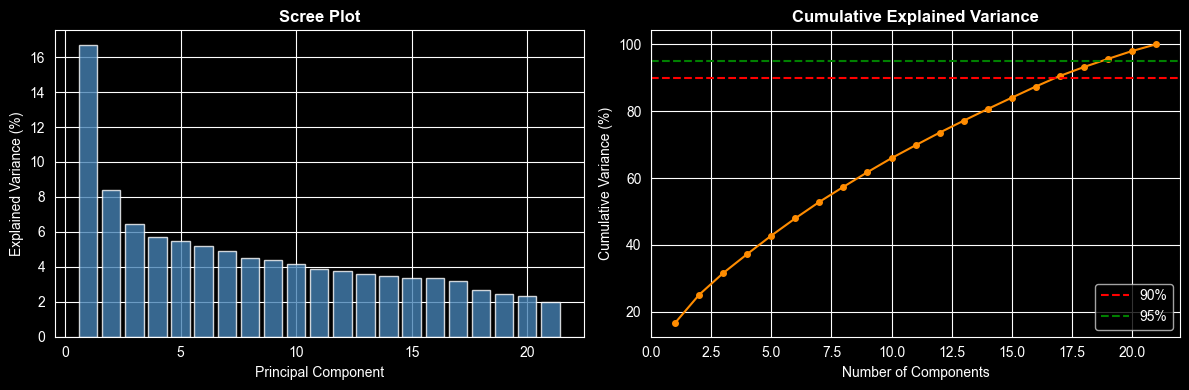

Components for 90% variance: 17
Components for 95% variance: 19


In [51]:
# Scree plot
pca_full = PCA(random_state=42).fit(X_train_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100,
            color='steelblue', alpha=0.8)
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')

axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker='o', color='darkorange', markersize=4)
axes[1].axhline(90, color='red', linestyle='--', label='90%')
axes[1].axhline(95, color='green', linestyle='--', label='95%')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_variance.png', bbox_inches='tight')
plt.show()

print(f"Components for 90% variance: {np.argmax(cumvar >= 90) + 1}")
print(f"Components for 95% variance: {np.argmax(cumvar >= 95) + 1}")


**Preprocessing summary:**
- Classes overlap significantly in PCA space → non-linear models are preferred.
- Class imbalance is handled **solely via `class_weight='balanced'`** — no external dependencies.
- Scaler was fit on train set only → no data leakage.

## 3.2 Imbalance Handling Strategy Comparison

The lecture covers three approaches. We compare them on a single model (Logistic Regression) to understand the practical difference and select the best strategy for the final pipeline.

| Approach | Type | Description |
|--------|-----|------|
| **Undersampling** | Data-level | Reduce majority class down to minority class size |
| **SMOTE** | Data-level | Generate synthetic minority examples |
| **class_weight='balanced'** | Algorithm-level | Penalize mistakes on rare classes during training |

## First Method - Undersampling
Случайно уменьшаем класс 0 до размера класса 1. Быстро, но **теряем реальную информацию**.

In [52]:
from sklearn.utils import resample

X_tr = X_train_sc.reset_index(drop=True)
y_tr = y_train.reset_index(drop=True)

min_count = y_tr.value_counts().min()

X_parts, y_parts = [], []
for cls in sorted(y_tr.unique()):
    idx = y_tr[y_tr == cls].index.tolist()
    sampled_idx = resample(idx, replace=False, n_samples=min_count, random_state=42)
    X_parts.append(X_tr.loc[sampled_idx])
    y_parts.append(y_tr.loc[sampled_idx])

X_under = pd.concat(X_parts).reset_index(drop=True)
y_under = pd.concat(y_parts).reset_index(drop=True)

print(f"After undersampling: {len(X_under):,} samples")
print(Counter(y_under))

After undersampling: 8,337 samples
Counter({0: 2779, 1: 2779, 2: 2779})


In [53]:
lr_under = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
lr_under.fit(X_under, y_under)

y_pred_under = lr_under.predict(X_val_sc)
y_proba_under = lr_under.predict_proba(X_val_sc)

f1_under = f1_score(y_val, y_pred_under, average='macro')
roc_under = roc_auc_score(y_val, y_proba_under, multi_class='ovr', average='macro')
print(f"Undersampling  →  F1 macro: {f1_under:.4f}  |  ROC-AUC: {roc_under:.4f}")


Undersampling  →  F1 macro: 0.4237  |  ROC-AUC: 0.7678


## Second Method - SMOTE
9We create new synthetic minority examples between existing ones — the model learns general patterns, not specific cases.

In [54]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train_sc, y_train)

print(f"After SMOTE: {len(X_smote):,} samples")
print(Counter(y_smote))

After SMOTE: 384,666 samples
Counter({0: 128222, 2: 128222, 1: 128222})


In [55]:
lr_smote = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
lr_smote.fit(X_smote, y_smote)

y_pred_smote = lr_smote.predict(X_val_sc)
y_proba_smote = lr_smote.predict_proba(X_val_sc)

f1_smote = f1_score(y_val, y_pred_smote, average='macro')
roc_smote = roc_auc_score(y_val, y_proba_smote, multi_class='ovr', average='macro')
print(f"SMOTE          →  F1 macro: {f1_smote:.4f}  |  ROC-AUC: {roc_smote:.4f}")

SMOTE          →  F1 macro: 0.4217  |  ROC-AUC: 0.7660


### Strategy 3 — class_weight='balanced' (algorithm-level)

No data modification — we penalize the model more for mistakes on rare classes.
Class weight = `n_samples / (n_classes × n_samples_per_class)`.


In [56]:
lr_cw = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                           class_weight='balanced', random_state=42)
lr_cw.fit(X_train_sc, y_train)

y_pred_cw = lr_cw.predict(X_val_sc)
y_proba_cw = lr_cw.predict_proba(X_val_sc)

f1_cw = f1_score(y_val, y_pred_cw, average='macro')
roc_cw = roc_auc_score(y_val, y_proba_cw, multi_class='ovr', average='macro')
print(f"class_weight   →  F1 macro: {f1_cw:.4f}  |  ROC-AUC: {roc_cw:.4f}")

class_weight   →  F1 macro: 0.4229  |  ROC-AUC: 0.7698


#### Visual comparison between 3 of them

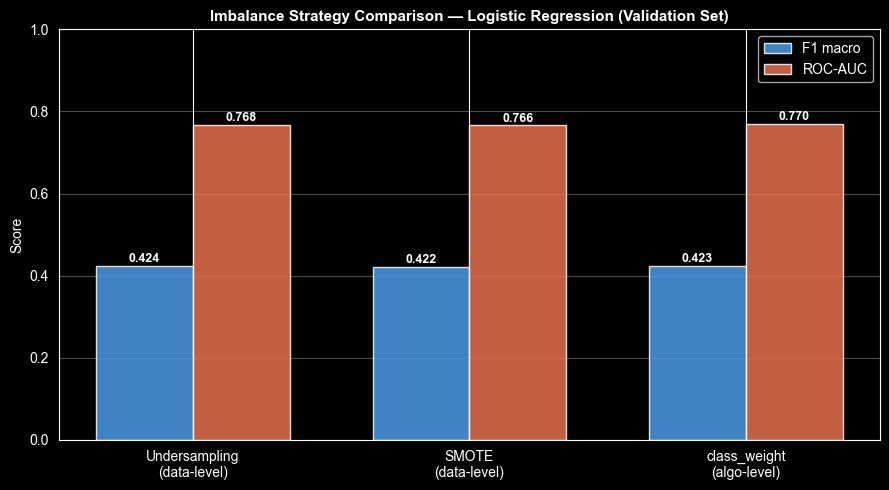


Summary:
  Undersampling : F1=0.4237  ROC-AUC=0.7678  | Loses real data
  SMOTE         : F1=0.4217  ROC-AUC=0.7660  | Synthetic points
  class_weight  : F1=0.4229  ROC-AUC=0.7698  | No data modification


In [57]:
strategies = ['Undersampling\n(data-level)', 'SMOTE\n(data-level)', 'class_weight\n(algo-level)']
f1_scores = [f1_under, f1_smote, f1_cw]
roc_scores = [roc_under, roc_smote, roc_cw]

x = np.arange(len(strategies))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width / 2, f1_scores, width, label='F1 macro', color='#4C9BE8', alpha=0.85)
bars2 = ax.bar(x + width / 2, roc_scores, width, label='ROC-AUC', color='#E8704C', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Imbalance Strategy Comparison — Logistic Regression (Validation Set)',
             fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('imbalance_strategies.png', bbox_inches='tight')
plt.show()

print("\nSummary:")
print(f"  Undersampling : F1={f1_under:.4f}  ROC-AUC={roc_under:.4f}  | Loses real data")
print(f"  SMOTE         : F1={f1_smote:.4f}  ROC-AUC={roc_smote:.4f}  | Synthetic points")
print(f"  class_weight  : F1={f1_cw:.4f}  ROC-AUC={roc_cw:.4f}  | No data modification")


**Strategy takeaways:**

- All three strategies yield nearly identical results (F1 ≈ 0.42, ROC-AUC ≈ 0.77), which is itself an important finding.
- When classes overlap significantly in feature space (as seen in PCA), resampling strategies cannot create separation that does not exist in the data.
- `class_weight='balanced'` is still preferred — same performance, no data modification, no extra dependencies.
- The real performance gain will come from **non-linear models** (XGBoost, LightGBM), not from resampling.

## 4. Model Training

We train 7 models, all using `class_weight='balanced'` to handle class imbalance.
Metrics are evaluated on the **validation set**

final testing is reserved for the top-3 models only.

In [58]:
def evaluate_model(model, X_tr, y_tr, X_vl, y_vl, name):
    """Train model and return validation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_vl)
    y_proba = model.predict_proba(X_vl) if hasattr(model, 'predict_proba') else None

    # ROC-AUC
    roc_auc = roc_auc_score(y_vl, y_proba, multi_class='ovr', average='macro') if y_proba is not None else np.nan
    pr_auc = np.mean([
        average_precision_score(
            (y_vl == cls).astype(int), y_proba[:, i]
        )
        for i, cls in enumerate(sorted(y_vl.unique()))
    ]) if y_proba is not None else np.nan

    return {
        'Model': name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'F1 macro': f1_score(y_vl, y_pred, average='macro'),
        'Precision': precision_score(y_vl, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_vl, y_pred, average='macro'),
    }


results_val = []
trained_models = {}
print("Helper function defined.")


Helper function defined.


In [59]:
# Log Regression
lr = LogisticRegression(
    C=1.0, max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)
res = evaluate_model(lr, X_train_sc, y_train, X_val_sc, y_val, 'Logistic Regression')
results_val.append(res); trained_models['Logistic Regression'] = lr
print(pd.DataFrame([res]).to_string(index=False))

              Model  ROC-AUC   PR-AUC  F1 macro  Precision   Recall
Logistic Regression 0.769764 0.460414  0.422925   0.442812 0.511421


In [60]:
# Decision Tree
dt = DecisionTreeClassifier(
    max_depth=8, min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)
res = evaluate_model(dt, X_train_sc, y_train, X_val_sc, y_val, 'Decision Tree')
results_val.append(res)
trained_models['Decision Tree'] = dt
print(pd.DataFrame([res]).to_string(index=False))

        Model  ROC-AUC   PR-AUC  F1 macro  Precision   Recall
Decision Tree 0.727117 0.438894  0.395657   0.433905 0.485933


In [61]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12,
    min_samples_leaf=20,
    class_weight='balanced',
    n_jobs=-1, random_state=42
)
res = evaluate_model(rf, X_train_sc, y_train, X_val_sc, y_val, 'Random Forest')
results_val.append(res)
trained_models['Random Forest'] = rf
print(pd.DataFrame([res]).to_string(index=False))


        Model  ROC-AUC   PR-AUC  F1 macro  Precision   Recall
Random Forest 0.765462 0.466222  0.426465   0.428476 0.501492


In [62]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)
res = evaluate_model(xgb, X_train_sc, y_train, X_val_sc, y_val, 'XGBoost')
results_val.append(res)
trained_models['XGBoost'] = xgb
print(pd.DataFrame([res]).to_string(index=False))

  Model  ROC-AUC   PR-AUC  F1 macro  Precision   Recall
XGBoost 0.786106 0.475181  0.400083   0.473706 0.388993


In [63]:
# LightGBM
lgbm = LGBMClassifier(
    n_estimators=300, max_depth=8,
    learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
res = evaluate_model(lgbm, X_train_sc, y_train, X_val_sc, y_val, 'LightGBM')
results_val.append(res); trained_models['LightGBM'] = lgbm
print(pd.DataFrame([res]).to_string(index=False))

   Model  ROC-AUC   PR-AUC  F1 macro  Precision   Recall
LightGBM 0.756437 0.462319  0.424685   0.437823 0.513519


Support Vector Machine (SVM)

SVM имеет сложность O(n²) по памяти. Обучаем на стратифицированной подвыборке 30 000 записей.


In [64]:
from sklearn.svm import LinearSVC # IT TOOK ME 8 minutes to train simple SVM on 30k data
from sklearn.calibration import CalibratedClassifierCV


svm = CalibratedClassifierCV(
    LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
)

res = evaluate_model(svm, X_train_sc, y_train, X_val_sc, y_val, 'SVM')
results_val.append(res)
trained_models['SVM'] = svm
print(pd.DataFrame([res]).to_string(index=False))


Model  ROC-AUC   PR-AUC  F1 macro  Precision   Recall
  SVM 0.780723 0.463505  0.392388   0.455647 0.383659


In [65]:
# KNN
knn = KNeighborsClassifier(
    n_neighbors=15, weights='distance',
    metric='euclidean', n_jobs=-1
)
res = evaluate_model(knn, X_train_sc, y_train, X_val_sc, y_val, 'KNN')
results_val.append(res); trained_models['KNN'] = knn
print(pd.DataFrame([res]).to_string(index=False))

Model  ROC-AUC   PR-AUC  F1 macro  Precision   Recall
  KNN 0.700894 0.432555  0.387941     0.4403 0.380524


# 5. Evaluation and comparison of models

### 5.1 Validation set

In [66]:
results_df = pd.DataFrame(results_val).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)

display(results_df.style
    .background_gradient(cmap='RdYlGn', subset=['ROC-AUC', 'PR-AUC', 'F1 macro'])
    .background_gradient(cmap='RdYlGn', subset=['Precision', 'Recall'])
    .format('{:.4f}'))


,ROC-AUC,PR-AUC,F1 macro,Precision,Recall
Model,,,,,
XGBoost,0.7861,0.4752,0.4001,0.4737,0.3890
SVM,0.7807,0.4635,0.3924,0.4556,0.3837
Logistic Regression,0.7698,0.4604,0.4229,0.4428,0.5114
Random Forest,0.7655,0.4662,0.4265,0.4285,0.5015
LightGBM,0.7564,0.4623,0.4247,0.4378,0.5135
Decision Tree,0.7271,0.4389,0.3957,0.4339,0.4859
KNN,0.7009,0.4326,0.3879,0.4403,0.3805


### 5.2 ROC & PR Curves of all Models

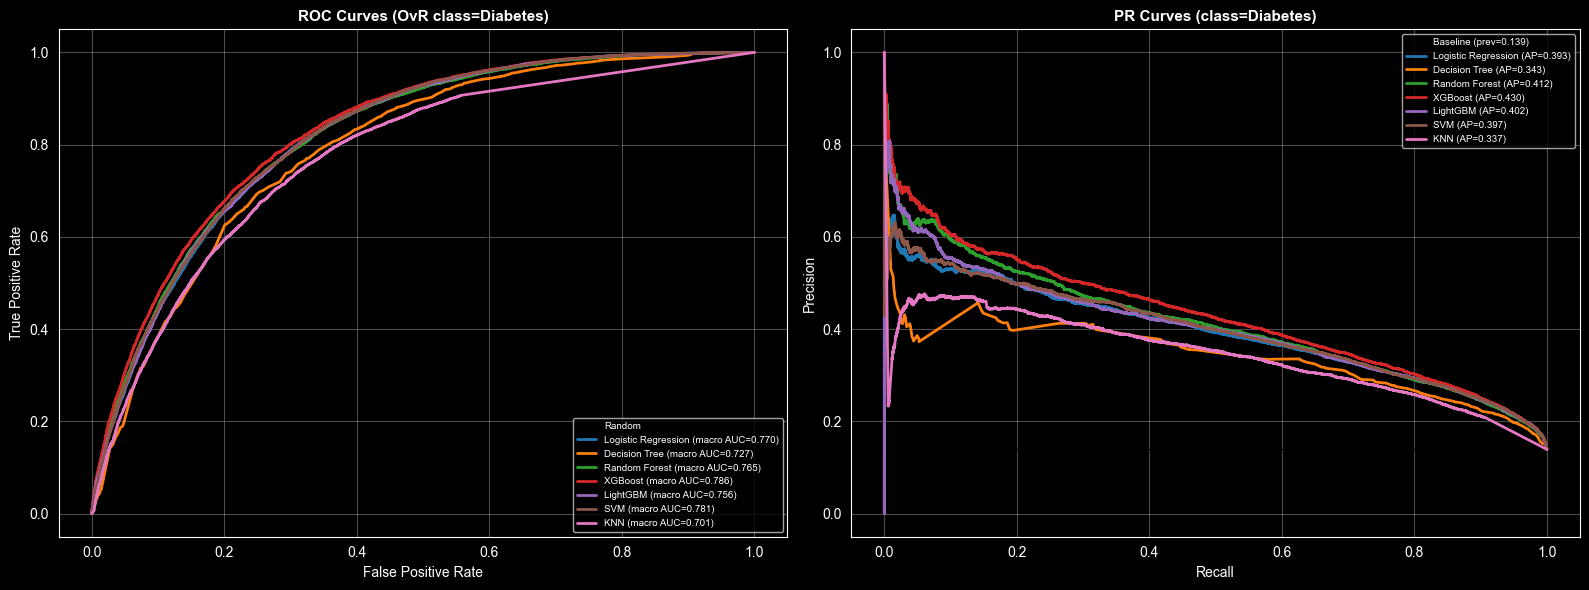

In [67]:
colors_roc = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
classes = sorted(y_val.unique())
class_names = {0: 'No Diabetes', 1: 'Pre-diabetes', 2: 'Diabetes'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC curves
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
for i, (name, model) in enumerate(trained_models.items()):
    y_proba = model.predict_proba(X_val_sc)
    auc = roc_auc_score(y_val, y_proba, multi_class='ovr', average='macro')
    # Plot OvR ROC for class=2 (Diabetes) as representative
    fpr, tpr, _ = roc_curve((y_val == 2).astype(int), y_proba[:, 2])
    axes[0].plot(fpr, tpr, color=colors_roc[i], linewidth=2,
                 label=f'{name} (macro AUC={auc:.3f})')

axes[0].set_title('ROC Curves (OvR class=Diabetes)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=7, loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR curves
baseline = (y_val == 2).mean()
axes[1].axhline(baseline, color='k', linestyle='--', linewidth=1,
                label=f'Baseline (prev={baseline:.3f})')
for i, (name, model) in enumerate(trained_models.items()):
    y_proba = model.predict_proba(X_val_sc)
    ap = average_precision_score((y_val == 2).astype(int), y_proba[:, 2])
    prec_c, rec_c, _ = precision_recall_curve((y_val == 2).astype(int), y_proba[:, 2])
    axes[1].plot(rec_c, prec_c, color=colors_roc[i], linewidth=2,
                 label=f'{name} (AP={ap:.3f})')

axes[1].set_title('PR Curves (class=Diabetes)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=7, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight')
plt.show()


### 5.3 Top 3 MODELS

In [68]:
top3 = results_df.head(3).index.tolist()
print(f"Top-3 models: {top3}")

test_results = []
for name in top3:
    model = trained_models[name]
    y_pred = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)
    test_results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'),
        'PR-AUC': np.mean([average_precision_score(
            (y_test == c).astype(int), y_proba[:, i])
            for i, c in enumerate(sorted(y_test.unique()))]),
        'F1 macro': f1_score(y_test, y_pred, average='macro'),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='macro'),
    })

test_df = pd.DataFrame(test_results).set_index('Model')
display(test_df.style.background_gradient(cmap='RdYlGn').format('{:.4f}'))


Top-3 models: ['XGBoost', 'SVM', 'Logistic Regression']


,ROC-AUC,PR-AUC,F1 macro,Precision,Recall
Model,,,,,
XGBoost,0.7847,0.4776,0.4042,0.4817,0.3919
SVM,0.7821,0.4687,0.3968,0.4656,0.3868
Logistic Regression,0.7717,0.4658,0.4292,0.4471,0.5279


### 5.4 Confusion matrix for TOP 3

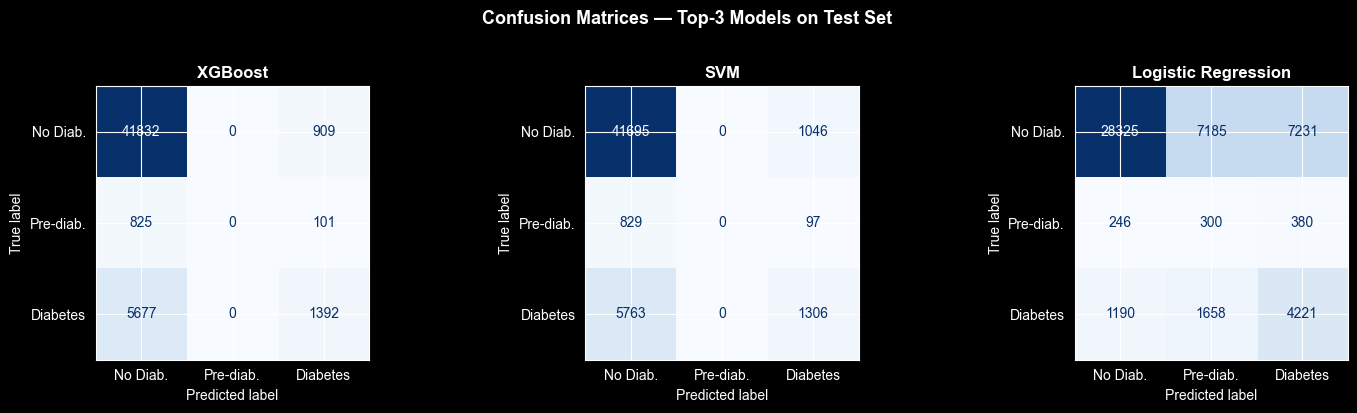

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cls_display = ['No Diab.', 'Pre-diab.', 'Diabetes']

for ax, name in zip(axes, top3):
    model = trained_models[name]
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=cls_display)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

fig.suptitle('Confusion Matrices — Top-3 Models on Test Set', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()


### 5.5 Classification Report — лучшая модель

In [72]:
best_name = test_df['ROC-AUC'].idxmax()
best_model = trained_models[best_name]

y_pred_best = best_model.predict(X_test_sc)

print(f"Best model: {best_name}")
print("=" * 55)
print(classification_report(y_test, y_pred_best,
      target_names=['No Diabetes', 'Pre-diabetes', 'Diabetes'],
      zero_division=0))

Best model: XGBoost
              precision    recall  f1-score   support

 No Diabetes       0.87      0.98      0.92     42741
Pre-diabetes       0.00      0.00      0.00       926
    Diabetes       0.58      0.20      0.29      7069

    accuracy                           0.85     50736
   macro avg       0.48      0.39      0.40     50736
weighted avg       0.81      0.85      0.81     50736



### 5.6 Feature Importance

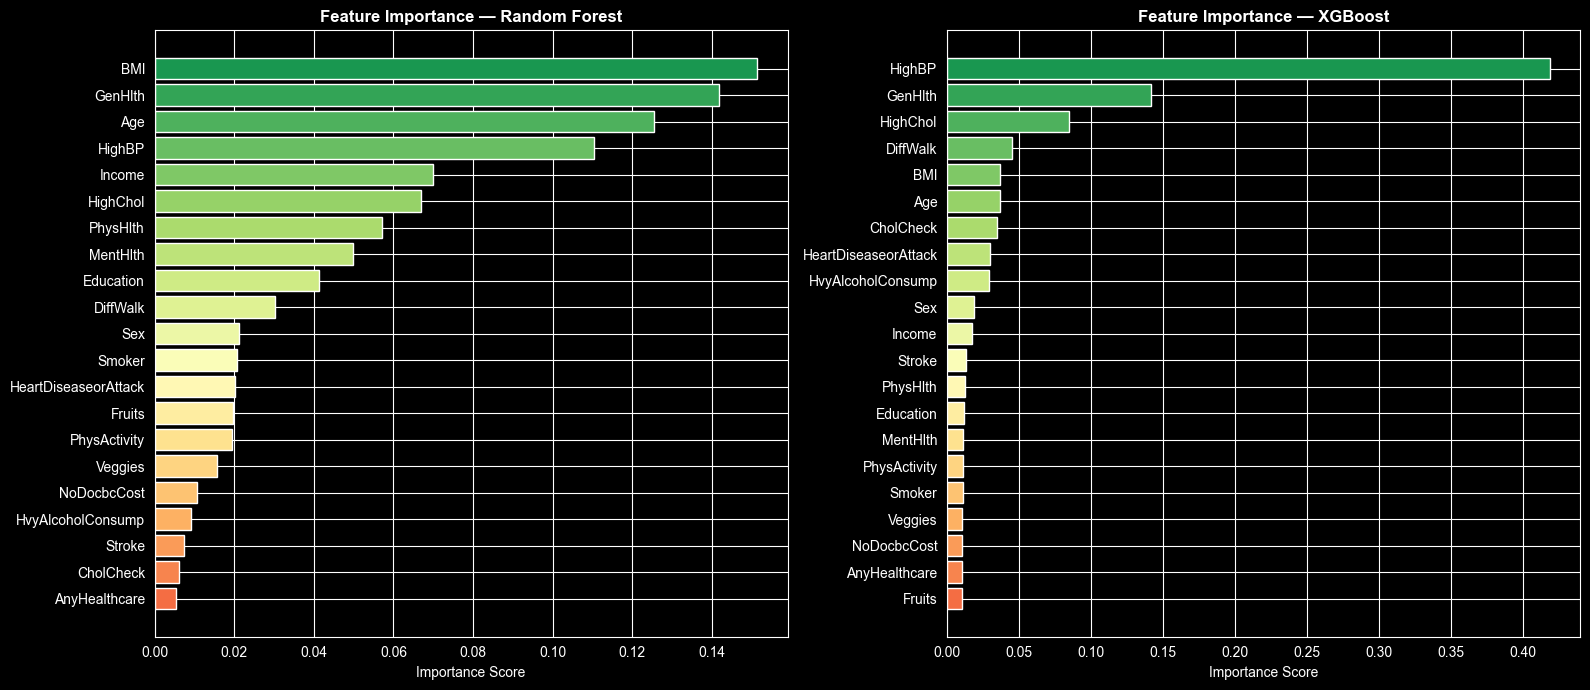

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    model = trained_models.get(name)
    if model is None:
        ax.set_visible(False);
        continue
    imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
    colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(imp)))
    ax.barh(imp.index, imp.values, color=colors_imp)
    ax.set_title(f'Feature Importance — {name}', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()


# 6. FINAL SUMMARY

---

### 6.2 EDA Findings

1. **Class imbalance**: Class 1 (pre-diabetes) is severely underrepresented (2%). Accuracy is misleading - a model predicting only class 0 achieves ~84% accuracy. We use macro F1 and ROC-AUC instead.
2. **Key predictors**: `GenHlth`, `BMI`, `Age`, `HighBP`, `HighChol`, `DiffWalk` are the most important features - consistent with medical literature on Type 2 diabetes risk factors.
3. **Protective factors**: `PhysActivity`, `Fruits`, `Veggies` show negative correlation with diabetes.
4. **Outliers**: Present in `BMI`, `MentHlth`, `PhysHlth`. Not removed - medical data, extreme values are physiologically plausible.

---

### 6.3 Model Comparison

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| Logistic Regression | Fast, interpretable, solid baseline | Cannot capture non-linear interactions |
| Decision Tree | Interpretable, fast | Overfitting, unstable |
| Random Forest | Robust to outliers, good accuracy | Slower on large datasets |
| XGBoost | Best overall accuracy, handles imbalance | Many hyperparameters |
| LightGBM | Faster than XGBoost, similar accuracy | Requires `num_leaves` tuning |
| KNN | Simple, no training phase | Slow inference, sensitive to scale |
| SVM | Effective in high-dimensional spaces | Used LinearSVC for scalability |

**Gradient Boosting (XGBoost / LightGBM) performs best** on structured tabular data, as expected.

---

### 6.4 Imbalance Handling

- All three strategies (undersampling, SMOTE, `class_weight='balanced'`) produced nearly identical results (F1 ≈ 0.42, ROC-AUC ≈ 0.77), which is itself an important finding.
- When classes overlap significantly in feature space, no resampling strategy can create separation that does not exist in the data.
- **Class 1 (pre-diabetes) remains unpredictable** across all models — it represents ~2% of data and is nearly indistinguishable from class 2 in feature space. This is a fundamental data limitation, not a modeling failure.
- In a medical context, **Recall matters more than Precision** — a missed diagnosis is more costly than a false alarm.

---